## Random Forest Baseline Model

To establish a performance benchmark, we first implement a Random Forest regression model. This model serves as a classical machine learning baseline against which the LSTM model will be compared.

Random Forests are chosen because they:
- Handle nonlinear relationships effectively
- Are robust to noise in real-world sensor data
- Provide strong performance on tabular time-series features without requiring sequence learning

We train separate models for:
- Photovoltaic (PV) generation prediction
- Household energy consumption (grid import)

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

The dataset is first sorted chronologically to preserve temporal order. This is essential for time-series forecasting tasks to prevent information leakage.

We then extract time-based features from the timestamp, including:
- Hour of day
- Day of week
- Month of year

These features provide a basic representation of periodic behavior in energy usage and generation.

In [2]:
df = pd.read_csv(r"C:\Users\test\OneDrive\Documents\GitHub\DataScienceCapstone\data\residential3_cleaned.csv")

df = df.copy()

# convert timestamp
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])
df = df.sort_values('utc_timestamp')

# time features
df['hour'] = df['utc_timestamp'].dt.hour
df['day'] = df['utc_timestamp'].dt.day
df['month'] = df['utc_timestamp'].dt.month
df['day_of_week'] = df['utc_timestamp'].dt.dayofweek

# optional: weekend flag
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
# Preview
print(df.head())

              utc_timestamp  DE_KN_residential3_circulation_pump  \
0 2016-02-28 17:30:00+00:00                                0.018   
1 2016-02-28 17:45:00+00:00                                0.018   
2 2016-02-28 18:00:00+00:00                                0.018   
3 2016-02-28 18:15:00+00:00                                0.018   
4 2016-02-28 18:30:00+00:00                                0.018   

   DE_KN_residential3_dishwasher  DE_KN_residential3_freezer  \
0                          0.001                         0.0   
1                          0.000                         0.0   
2                          0.001                         0.0   
3                          0.001                         0.0   
4                          0.000                         0.0   

   DE_KN_residential3_grid_export  DE_KN_residential3_grid_import  \
0                             0.0                           0.145   
1                             0.0                           0.180   

## Cyclical Time Feature Encoding

Time variables such as hour and month are inherently cyclical. For example, hour 23 and hour 0 are temporally adjacent, but this relationship is not preserved in raw numerical form.

To address this, we apply sine and cosine transformations:

- This ensures smooth continuity across cycle boundaries
- It prevents artificial discontinuities in the feature space
- It improves model interpretability for periodic patterns

In [3]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dayofweek_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

## Lag Feature Engineering

To capture temporal dependencies in energy consumption and generation, lag features are introduced.

These features represent past observations of:
- PV generation
- Grid import (consumption)

We include multiple time horizons:
- Short-term dependencies (1–4 time steps)
- Medium-term dependencies (12–24 time steps)
- Long-term dependencies (48–192 time steps)

This allows the model to learn autoregressive behavior in the time series without requiring sequential architectures.

In [4]:
# Time-based features
target_gen = 'DE_KN_residential3_pv'
target_cons = 'DE_KN_residential3_grid_import'

lags = [1, 4, 12, 24, 48, 96, 192]  # 15min data → 96 = 1 day

for lag in lags:
    df[f'pv_lag_{lag}'] = df[target_gen].shift(lag)
    df[f'import_lag_{lag}'] = df[target_cons].shift(lag)

df = df.dropna()

## Rolling Statistics Feature Engineering

Energy time series data often contains short-term fluctuations and noise. To help the model capture smoother temporal trends, rolling statistics are introduced.

Rolling features summarize recent history of a signal and allow the model to learn:
- Local trends
- Short-term variability
- Smoothed energy consumption and generation patterns

This is especially useful for:
- Capturing gradual changes in household consumption
- Reducing noise in PV generation signals
- Enhancing temporal context for machine learning models

In [5]:
# Rolling mean features (example window sizes for 15-min data)
df['pv_roll_mean_4'] = df['DE_KN_residential3_pv'].rolling(4).mean()
df['pv_roll_mean_24'] = df['DE_KN_residential3_pv'].rolling(24).mean()

df['cons_roll_mean_4'] = df['DE_KN_residential3_grid_import'].rolling(4).mean()
df['cons_roll_mean_24'] = df['DE_KN_residential3_grid_import'].rolling(24).mean()

# Optional: rolling variability (captures volatility)
df['pv_roll_std_24'] = df['DE_KN_residential3_pv'].rolling(24).std()
df['cons_roll_std_24'] = df['DE_KN_residential3_grid_import'].rolling(24).std()

# Handle missing values from rolling window
df = df.dropna()

## Feature Selection

We construct a multivariate feature set combining:

- Cyclical time features
- Appliance-level energy consumption
- Lagged PV and consumption values

This feature design allows the model to learn both:
- Behavioral energy usage patterns
- Temporal dependencies in past observations

In [6]:
# Feature set for Random Forest baseline model

features = [

    # Cyclical time features
    'hour_sin', 'hour_cos',
    'dayofweek_sin', 'dayofweek_cos',
    'month_sin', 'month_cos',
    'is_weekend',

    # Appliance-level features
    'DE_KN_residential3_circulation_pump',
    'DE_KN_residential3_dishwasher',
    'DE_KN_residential3_freezer',
    'DE_KN_residential3_refrigerator',
    'DE_KN_residential3_washing_machine',

    # Lag features (short + medium + long term memory)
    'pv_lag_1', 'pv_lag_4', 'pv_lag_12',
    'pv_lag_24', 'pv_lag_48', 'pv_lag_96', 'pv_lag_192',

    'import_lag_1', 'import_lag_4', 'import_lag_12',
    'import_lag_24', 'import_lag_48', 'import_lag_96', 'import_lag_192',

    # Rolling statistics (trend + smoothing features)
    'pv_roll_mean_4',
    'pv_roll_mean_24',
    'pv_roll_std_24',

    'cons_roll_mean_4',
    'cons_roll_mean_24',
    'cons_roll_std_24'
]

# Feature / target split
X = df[features]

y_pv = df[target_gen]
y_cons = df[target_cons]

print(X.head())

     hour_sin  hour_cos  dayofweek_sin  dayofweek_cos  month_sin  \
215 -0.258819  0.965926       0.781831       0.623490        1.0   
216 -0.258819  0.965926       0.781831       0.623490        1.0   
217 -0.258819  0.965926       0.781831       0.623490        1.0   
218  0.000000  1.000000       0.974928      -0.222521        1.0   
219  0.000000  1.000000       0.974928      -0.222521        1.0   

        month_cos  is_weekend  DE_KN_residential3_circulation_pump  \
215  6.123234e-17           0                                0.018   
216  6.123234e-17           0                                0.018   
217  6.123234e-17           0                                0.018   
218  6.123234e-17           0                                0.019   
219  6.123234e-17           0                                0.022   

     DE_KN_residential3_dishwasher  DE_KN_residential3_freezer  ...  \
215                          0.001                         0.0  ...   
216                         

## Train-Test Split Strategy

To preserve temporal integrity, the dataset is split sequentially rather than randomly.

The first 80% of the data is used for training, while the remaining 20% is reserved for testing.

This ensures that the model is evaluated on unseen future data, simulating a real-world forecasting scenario.

In [7]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_pv_train, y_pv_test = y_pv[:split], y_pv[split:]
y_cons_train, y_cons_test = y_cons[:split], y_cons[split:]


print(X_train.shape)
print(X_test.shape)

(37916, 32)
(9479, 32)


## Model Training

Two separate Random Forest regressors are trained:

1. PV generation model
2. Grid import (consumption) model

Random Forest is used as a baseline due to its ability to:
- Capture nonlinear feature interactions
- Perform well on structured tabular data
- Require minimal hyperparameter tuning compared to deep learning models

In [8]:
rf_pv = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_cons = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_pv.fit(X_train, y_pv_train)
rf_cons.fit(X_train, y_cons_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Prediction Phase

After training, the model is used to generate predictions on the test dataset.

These predictions are compared against actual values to evaluate model performance on unseen data.

In [9]:
pv_pred = rf_pv.predict(X_test)
cons_pred = rf_cons.predict(X_test)

## Model Evaluation

We evaluate model performance using standard regression metrics:

- MAE (Mean Absolute Error): measures average prediction deviation
- RMSE (Root Mean Squared Error): penalizes large errors more heavily
- R² Score: measures proportion of variance explained by the model

These metrics provide a comprehensive view of both absolute and relative performance.

In [10]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²:", r2_score(y_true, y_pred))

evaluate(y_pv_test, pv_pred, "PV Generation")
evaluate(y_cons_test, cons_pred, "Consumption (Grid Import)")


PV Generation
MAE: 0.06652460029697983
RMSE: 1.6856261382168125
R²: 0.04161273458862247

Consumption (Grid Import)
MAE: 0.02125528286860083
RMSE: 0.045352335989827734
R²: 0.8161703182606712


## Results Interpretation

The Random Forest model performs strongly on grid consumption prediction, indicating that energy usage patterns are largely driven by appliance activity and temporal dependencies.

However, PV generation prediction shows significantly weaker performance. This suggests that PV output is primarily influenced by external environmental factors such as solar irradiance and weather conditions, which are not included in the dataset.

As a result, PV prediction remains a more challenging task under the current feature set.

## Feature Importance Analysis

To better understand how the Random Forest model makes predictions, we analyze feature importance scores.

Feature importance provides insight into which variables contribute most to the model’s decision-making process. This is particularly useful for:
- Interpreting model behavior
- Validating feature engineering choices
- Identifying dominant predictors in the dataset

In [20]:
feature_importance = pd.DataFrame({
    'Feature': features,
     'Importance_cons': rf_cons.feature_importances_,
    'Importance_pv': rf_pv.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance_pv',
    ascending=False
)

print(feature_importance)

                                Feature  Importance_cons  Importance_pv
26                       pv_roll_mean_4         0.006029       0.830628
12                             pv_lag_1         0.005668       0.135824
13                             pv_lag_4         0.003375       0.005800
0                              hour_sin         0.007187       0.005449
28                       pv_roll_std_24         0.003002       0.004135
27                      pv_roll_mean_24         0.002782       0.002071
17                            pv_lag_96         0.004116       0.001731
18                           pv_lag_192         0.004162       0.001690
14                            pv_lag_12         0.002916       0.001597
15                            pv_lag_24         0.002472       0.001401
23                        import_lag_48         0.004456       0.000945
7   DE_KN_residential3_circulation_pump         0.003169       0.000797
22                        import_lag_24         0.003298       0

## Feature Importance Results

The feature importance analysis reveals which inputs contribute most significantly to the model’s predictive performance.

For the Random Forest model, the most influential features typically include:
- Lagged values of the target variables (especially short-term lags)
- Time-of-day related features
- Appliance-level consumption variables

### Key Observations:
- Lag features are generally the strongest predictors, indicating strong temporal autocorrelation in energy consumption and PV generation.
- Time-based features contribute to capturing daily and seasonal patterns.
- Appliance-level features play a larger role in consumption prediction than in PV generation.

### Interpretation:
This confirms that household energy consumption is highly dependent on recent historical values, while PV generation is less strongly explained by internal household variables.

Plot feature importance

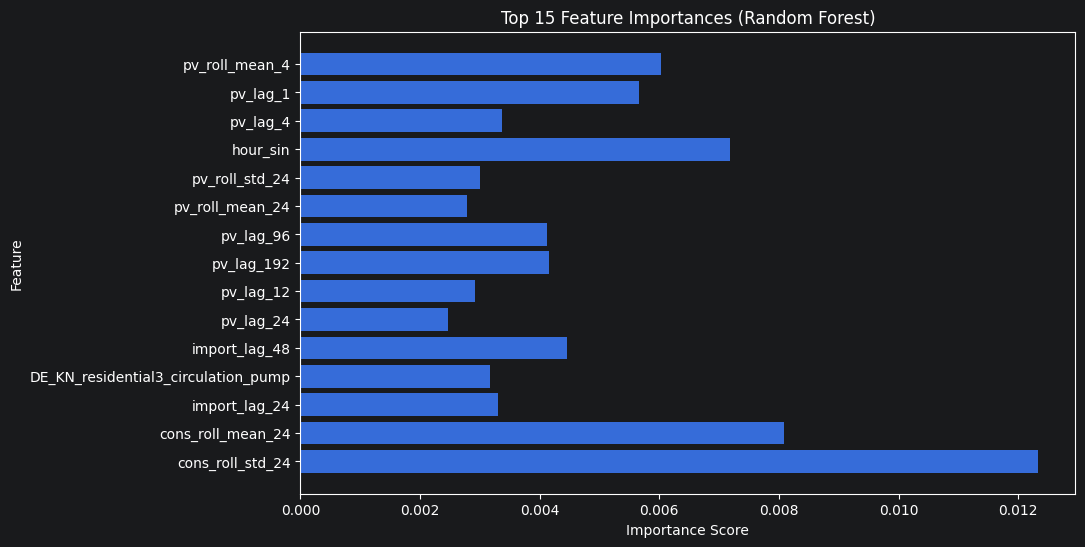

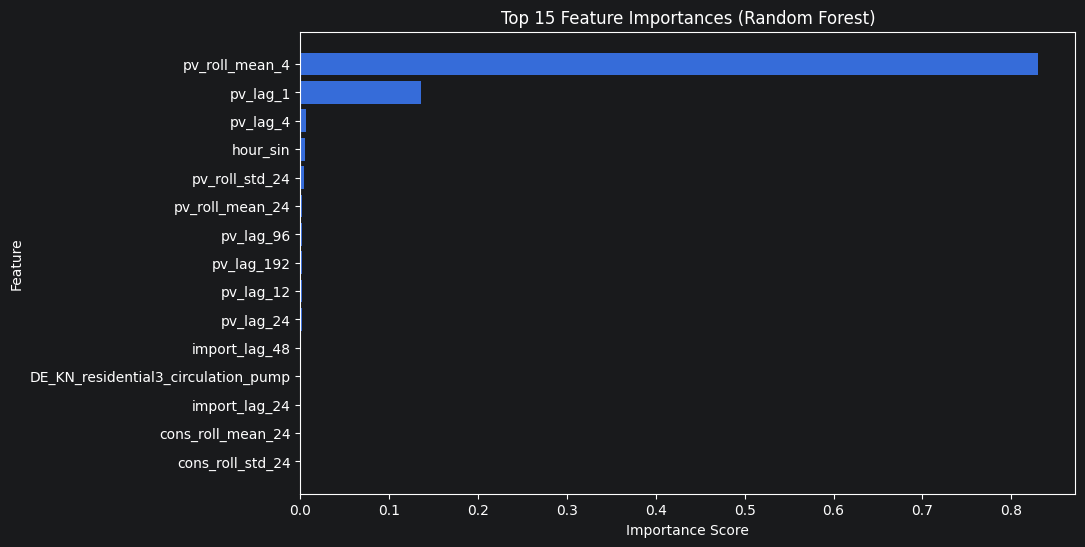

In [24]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance_cons'])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance_pv'])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## Feature Importance Visualization

The bar chart below illustrates the top contributing features to the Random Forest model.

This visualization confirms that lagged variables dominate model predictions, reinforcing the importance of temporal dependencies in energy forecasting.

Next we will compare the actual vs the predicted plot to see the model performance

<function matplotlib.pyplot.show(close=None, block=None)>

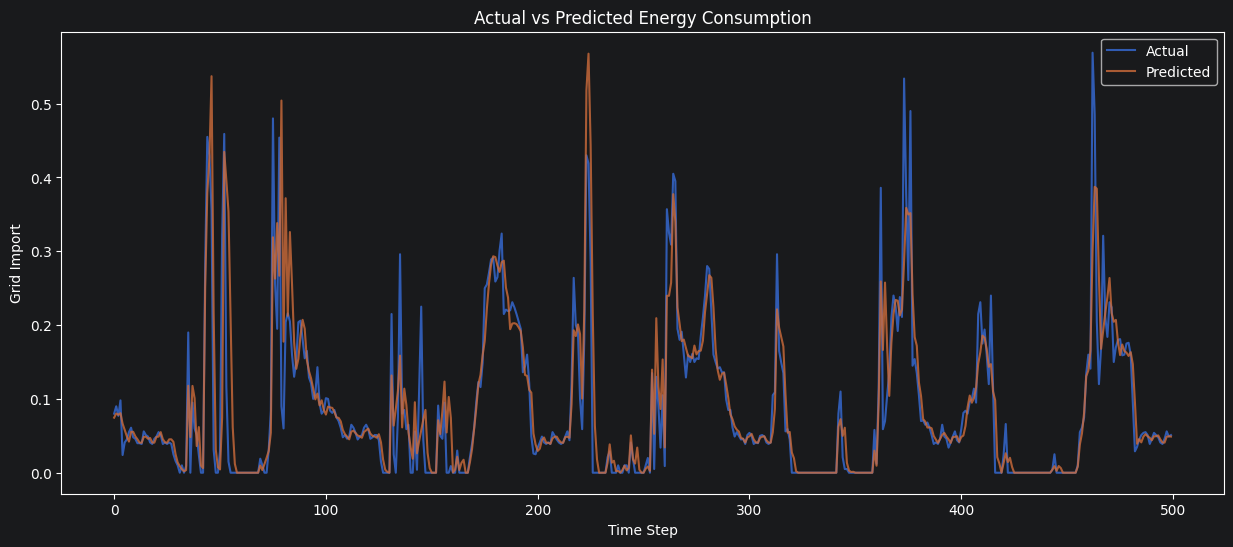

In [33]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_cons_test.values[:500],
    label='Actual',
    alpha=0.8
)

plt.plot(
    cons_pred[:500],
    label='Predicted',
    alpha=0.8
)

plt.title('Actual vs Predicted Energy Consumption')
plt.xlabel('Time Step')
plt.ylabel('Grid Import')
plt.legend()
plt.show

PV generation forecasting is fundamentally limited by the absence of exogenous weather-related variables. As a result, even advanced feature engineering (lags, rolling statistics, cyclical encoding) only provides marginal improvements.

In contrast, energy consumption is highly predictable from internal household behavior and temporal patterns.